In [2]:
import os
import numpy as np
import pickle
import sklearn
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Stress detection

Load the dataset

In the dataset we have measures and labels associated.
0 = not defined / transient, 1 = baseline, 2 = stress, 3 = amusement, 4 = meditation, 5/6/7 = should be ignored in this dataset

In [3]:
DATASET_PATH = "dataset/WESAD/"

We only keep what's interesting for us, ECG signal for each patient

In [4]:
patients_data = {}

for subject in os.listdir(DATASET_PATH):
    subject_path = os.path.join(DATASET_PATH, subject)

    if os.path.isdir(subject_path):
        file_path = os.path.join(subject_path, f"{subject}.pkl")

        if os.path.exists(file_path):
            with open(file_path, "rb") as f:
                data = pickle.load(f, encoding="latin1")

            ecg = data['signal']['chest']['ECG'].flatten()
            labels = data['label']

            df = pd.DataFrame({
                "ECG": ecg,
                "label": labels
            })

            patients_data[subject] = df
            
#Exemple
print(patients_data["S2"].head())

        ECG  label
0  0.021423      0
1  0.020325      0
2  0.016525      0
3  0.016708      0
4  0.011673      0


We see a lot of lable 0 (undefined)

In [5]:
df_s2 = patients_data["S2"]
proportions = df_s2["label"].value_counts(normalize=True)

print(proportions)

label
0    0.503537
1    0.188189
4    0.126336
2    0.101168
3    0.059549
6    0.010693
7    0.010528
Name: proportion, dtype: float64


More than 50% of our measures are label 0 and can't be used for patient 2, we'll delete them with label 5/6/7 as it's written in the readme of the dataset that they should be ignored.

In [6]:
labels_to_remove = [0, 5, 6, 7]

for subject in patients_data:
    df = patients_data[subject]
    
    # filtrage
    df_clean = df[~df["label"].isin(labels_to_remove)]
    
    # reset index (optionnel mais propre)
    df_clean = df_clean.reset_index(drop=True)
    
    patients_data[subject] = df_clean

df_s2 = patients_data["S2"]
proportions = df_s2["label"].value_counts(normalize=True)

print(proportions)

label
1    0.395985
4    0.265836
2    0.212877
3    0.125303
Name: proportion, dtype: float64


Let's visualize the data

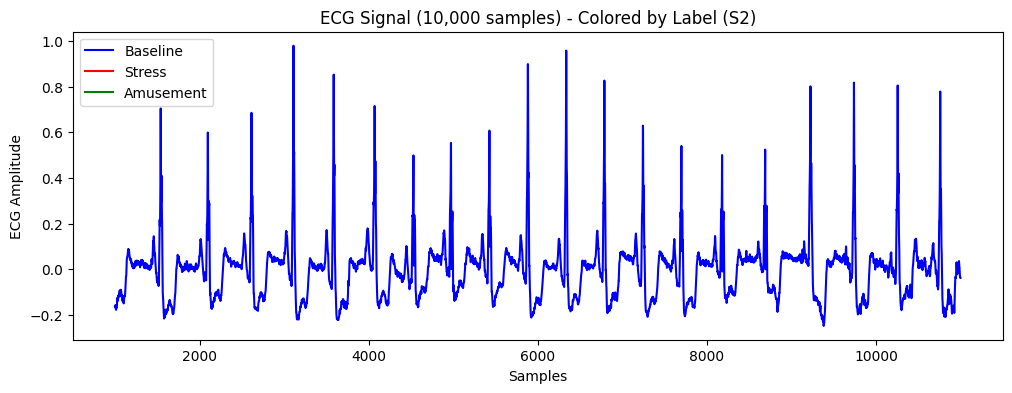

In [7]:
df_s2 = patients_data["S2"]

start = 1000
end = start + 10000

ecg = df_s2["ECG"].values[start:end]
labels = df_s2["label"].values[start:end]

colors = {1: "blue", 2: "red", 3: "green"}

plt.figure(figsize=(12, 4))

# tracer par segments de même label
i = 0
while i < len(ecg) - 1:
    j = i
    # trouver segment où label est constant
    while j < len(ecg) - 1 and labels[j] == labels[j + 1]:
        j += 1

    plt.plot(range(start + i, start + j + 1),
             ecg[i:j+1],
             color=colors.get(labels[i], "black"))

    i = j + 1

plt.title("ECG Signal (10,000 samples) - Colored by Label (S2)")
plt.xlabel("Samples")
plt.ylabel("ECG Amplitude")

legend_elements = [
    Line2D([0], [0], color='blue', label='Baseline'),
    Line2D([0], [0], color='red', label='Stress'),
    Line2D([0], [0], color='green', label='Amusement')
]

plt.legend(handles=legend_elements)

plt.show()

Feature engineering

Time-domain feature

RR intervals

In [8]:
sampling_rate = 700  # WESAD ECG sampling frequency in Hz (samplesper second)
patients_rr_intervals = {}

for subject, patient_df in patients_data.items():
    ecg_signal = patient_df["ECG"].to_numpy()
    labels_signal = patient_df["label"].to_numpy()

    peaks, _ = scipy.signal.find_peaks(
        ecg_signal,
        distance=int(0.3 * sampling_rate),
        prominence=max(0.15, 0.5 * np.std(ecg_signal)),
    )

    rr_interval_ms = np.diff(peaks) * 1000 / sampling_rate
    rr_labels = labels_signal[(peaks[:-1] + peaks[1:]) // 2]

    patients_rr_intervals[subject] = pd.DataFrame(
        {
            "rr_interval_ms": rr_interval_ms,
            "label": rr_labels,
        }   
    )

subject = "S2"
rr_df = patients_rr_intervals[subject]

print(f"{subject} - number of detected RR intervals: {len(rr_df)}")
display(rr_df.head())

S2 - number of detected RR intervals: 3578


,rr_interval_ms,label
0,841.428571,1
1,838.571429,1
2,795.714286,1
3,737.142857,1
4,710.000000,1


Other features - Heart Rate Variability

In [9]:
def compute_hrv_features(rr_intervals_ms):
    """
    Compute HRV features from RR intervals in milliseconds.
    
    Parameters:
    - rr_intervals_ms: numpy array of RR intervals in ms
    
    Returns:
    - dict with SDNN, RMSSD, pNN50, LF/HF ratio
    """
    rr_ms = np.array(rr_intervals_ms)
    
    rr_mean = np.mean(rr_ms)
    
    sdnn = np.std(rr_ms)
    
    diff_rr = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff_rr ** 2))
    
    pnn50 = 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr)
    
    fft_result = np.fft.fft(rr_ms)
    freqs = np.fft.fftfreq(len(rr_ms), d=np.mean(rr_ms) / 1000)
    power = np.abs(fft_result) ** 2
    
    lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
    hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
    
    lf_power = np.sum(power[lf_mask])
    hf_power = np.sum(power[hf_mask])
    
    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0
    
    return {
        "RR_mean": rr_mean,
        "SDNN": sdnn,
        "RMSSD": rmssd,
        "pNN50": pnn50,
        "LF/HF": lf_hf_ratio,
    }

hrv_features = {}
for subject, rr_df in patients_rr_intervals.items():
    rr_ms = rr_df["rr_interval_ms"].values
    if len(rr_ms) > 1:
        hrv_features[subject] = compute_hrv_features(rr_ms)

print("HRV Features for all subjects:")
for subject, features in hrv_features.items():
    print(f"\n{subject}:")
    for feature_name, value in features.items():
        print(f"  {feature_name}: {value:.2f}")


HRV Features for all subjects:

S10:
  RR_mean: 648.88
  SDNN: 115.35
  RMSSD: 43.15
  pNN50: 9.08
  LF/HF: 2.04

S11:
  RR_mean: 678.62
  SDNN: 160.77
  RMSSD: 51.14
  pNN50: 19.56
  LF/HF: 2.73

S13:
  RR_mean: 674.88
  SDNN: 114.52
  RMSSD: 54.78
  pNN50: 11.49
  LF/HF: 1.72

S14:
  RR_mean: 685.06
  SDNN: 160.33
  RMSSD: 34.38
  pNN50: 7.65
  LF/HF: 2.10

S15:
  RR_mean: 750.40
  SDNN: 112.07
  RMSSD: 72.18
  pNN50: 17.44
  LF/HF: 1.23

S16:
  RR_mean: 710.87
  SDNN: 205.40
  RMSSD: 53.45
  pNN50: 20.85
  LF/HF: 1.76

S17:
  RR_mean: 754.87
  SDNN: 231.99
  RMSSD: 96.34
  pNN50: 34.98
  LF/HF: 0.93

S2:
  RR_mean: 807.25
  SDNN: 145.62
  RMSSD: 140.99
  pNN50: 38.66
  LF/HF: 0.86

S3:
  RR_mean: 980.27
  SDNN: 253.33
  RMSSD: 135.91
  pNN50: 52.31
  LF/HF: 1.67

S4:
  RR_mean: 911.01
  SDNN: 154.29
  RMSSD: 96.89
  pNN50: 45.12
  LF/HF: 0.88

S5:
  RR_mean: 837.32
  SDNN: 167.58
  RMSSD: 138.57
  pNN50: 14.83
  LF/HF: 0.93

S6:
  RR_mean: 851.44
  SDNN: 105.47
  RMSSD: 56.54
  pNN5

We need to transform our dataset; we'll work on windows of time 

In [13]:
window_size = 10  # number of RR intervals per window
step_size = window_size  # use 1 for sliding windows

window_rows = []

for subject, rr_df in patients_rr_intervals.items():
    rr_values = rr_df["rr_interval_ms"].to_numpy()
    label_values = rr_df["label"].to_numpy()

    if len(rr_values) < window_size:
        continue

    for start_idx in range(0, len(rr_values) - window_size + 1, window_size):
        end_idx = start_idx + window_size
        rr_window = rr_values[start_idx:end_idx]
        label_window = label_values[start_idx:end_idx]

        # Majority label in the window
        majority_label = pd.Series(label_window).value_counts().idxmax()

        features = compute_hrv_features(rr_window)
        features["label"] = majority_label
        features["subject"] = subject
        features["start_idx"] = start_idx
        features["end_idx"] = end_idx

        window_rows.append(features)

wesad_window_df = pd.DataFrame(window_rows)

print("Windowed dataset shape:", wesad_window_df.shape)
display(wesad_window_df.head())
print("Label distribution:")
print(wesad_window_df["label"].value_counts(normalize=True))

wesad_window_df.to_csv("dataset/wesad_hrv_dataset_made_10.csv", index=False)

Windowed dataset shape: (5998, 9)


,RR_mean,SDNN,RMSSD,pNN50,LF/HF,label,subject,start_idx,end_idx
0,692.000000,50.391123,32.586880,11.111111,24.335479,1,S10,0,10
1,702.428571,42.947761,28.804604,11.111111,30.682599,1,S10,10,20
2,689.285714,13.676287,12.279807,0.000000,3.723826,1,S10,20,30
3,713.142857,14.023304,12.697421,0.000000,3.942371,1,S10,30,40
4,681.285714,16.092209,8.767596,0.000000,2.616591,1,S10,40,50


Label distribution:
label
1    0.374792
2    0.279593
4    0.230577
3    0.115038
Name: proportion, dtype: float64


We'll use Random Forest on this dataset

In [33]:
from copy import deepcopy
from sklearn.model_selection import GroupKFold


df_hrv = pd.read_csv("dataset/wesad_hrv_dataset_made_10.csv")

df_hrv = df_hrv[df_hrv["label"].isin([1, 2, 3, 4])].copy()
df_hrv["stress"] = (df_hrv["label"] == 2).astype(int)
df_hrv = df_hrv.dropna().reset_index(drop=True)

feature_cols = [c for c in df_hrv.columns if c not in ["label", "subject", "stress", "start_idx", "end_idx"]]
X = df_hrv[feature_cols]
y = df_hrv["stress"]
groups = df_hrv["subject"]

n_splits = min(6, groups.nunique())
if n_splits < 2:
    raise ValueError("Need at least 2 different subjects for GroupKFold.")

gkf = GroupKFold(n_splits=n_splits)

fold_scores = []
best_score = -np.inf
best_forest = None
best_fold = None

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    

    forest = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    forest.fit(X_train, y_train)
    fold_pred = forest.predict(X_test)
    fold_score = accuracy_score(y_test, fold_pred)

    fold_scores.append(fold_score)

    if fold_score > best_score:
        best_score = fold_score
        best_forest = deepcopy(forest)
        best_fold = fold_idx

print("Dataset shape:", df_hrv.shape)
print("Features:", feature_cols)
print("Number of subjects:", groups.nunique())
print("GroupKFold splits:", n_splits)
print("Accuracy per fold:", np.array(fold_scores))
print("Mean accuracy:", np.mean(fold_scores))
print("Std accuracy:", np.std(fold_scores))
print("Best fold:", best_fold)
print("Best fold accuracy:", best_score)
print("Best forest kept in variable: best_forest")

Dataset shape: (5998, 10)
Features: ['RR_mean', 'SDNN', 'RMSSD', 'pNN50', 'LF/HF']
Number of subjects: 15
GroupKFold splits: 6
Accuracy per fold: [0.8338945  0.74224978 0.81158168 0.84375    0.96539379 0.85317116]
Mean accuracy: 0.8416734843571384
Std accuracy: 0.0661996051224928
Best fold: 5
Best fold accuracy: 0.9653937947494033
Best forest kept in variable: best_forest


Accuracy on full dataset: 0.9951650550183394
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4321
           1       0.99      1.00      0.99      1677

    accuracy                           1.00      5998
   macro avg       0.99      1.00      0.99      5998
weighted avg       1.00      1.00      1.00      5998



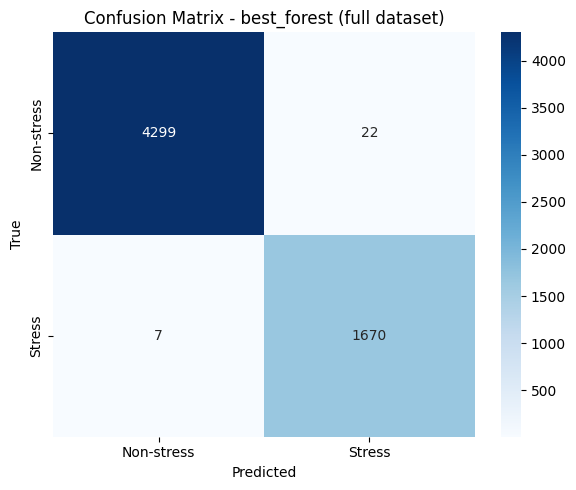

In [34]:
# Test best_forest on the full prepared dataset
y_pred_all = best_forest.predict(X)

print("Accuracy on full dataset:", accuracy_score(y, y_pred_all))
print(classification_report(y, y_pred_all))

cm = confusion_matrix(y, y_pred_all)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-stress", "Stress"],
    yticklabels=["Non-stress", "Stress"],
)
plt.title("Confusion Matrix - best_forest (full dataset)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

We try with unkown ECG

# Disease detection

Load the dataset

In [35]:
mitbih_train = pd.read_csv('dataset/mitbih/mitbih_train.csv', header=None)
mitbih_test = pd.read_csv('dataset/mitbih/mitbih_test.csv', header=None)
ptbdb_abnormal = pd.read_csv('dataset/mitbih/ptbdb_abnormal.csv', header=None)
ptbdb_normal = pd.read_csv('dataset/mitbih/ptbdb_normal.csv', header=None)

Data visualization

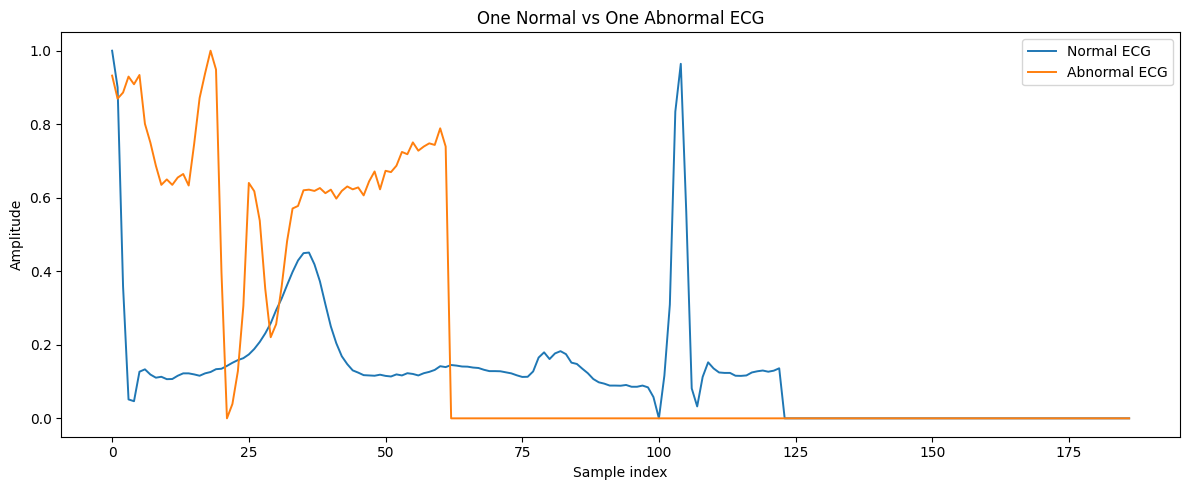

In [36]:
def extract_ecg_signal(row_values):
    if row_values.size > 1 and row_values[-1] in (0, 1):
        return row_values[:-1]
    return row_values

normal_signal = extract_ecg_signal(ptbdb_normal.iloc[0].to_numpy(dtype=float))
abnormal_signal = extract_ecg_signal(ptbdb_abnormal.iloc[0].to_numpy(dtype=float))

plt.figure(figsize=(12, 5))
plt.plot(normal_signal, label="Normal ECG", linewidth=1.4)
plt.plot(abnormal_signal, label="Abnormal ECG", linewidth=1.4)
plt.title("One Normal vs One Abnormal ECG")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
def print_dataset_info(name, df, has_label=True):
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

    missing_total = int(df.isna().sum().sum())
    print(f"Missing values (total): {missing_total}")

    if has_label:
        label_col = df.columns[-1]
        label_counts = df[label_col].value_counts().sort_index()
        print("Label distribution:")
        print(label_counts)
        print("Label distribution (%):")
        print((label_counts / len(df) * 100).round(2))

    print("First rows:")
    print(df.head(3))


print_dataset_info("MITBIH Train", mitbih_train, has_label=True)
print_dataset_info("MITBIH Test", mitbih_test, has_label=True)
print_dataset_info("PTBDB Abnormal", ptbdb_abnormal, has_label=True)
print_dataset_info("PTBDB Normal", ptbdb_normal, has_label=True)

ptbdb_all = pd.concat([ptbdb_normal, ptbdb_abnormal], ignore_index=True)
label_col = ptbdb_all.columns[-1]
print("\n=== PTBDB Combined (Normal + Abnormal) ===")
print(f"Shape: {ptbdb_all.shape}")
print("Label distribution:")
print(ptbdb_all[label_col].value_counts().sort_index())


=== MITBIH Train ===
Shape: (87554, 188)
Memory usage: 125.58 MB
Missing values (total): 0
Label distribution:
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64
Label distribution (%):
187
0.0    82.77
1.0     2.54
2.0     6.61
3.0     0.73
4.0     7.35
Name: count, dtype: float64
First rows:
        0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  187  
0  0.0  0.0  
1  0.0  0.

Physionet's MIT-BIH Arrhythmia Dataset
Classes: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]
N: Non-Ectopic Beats
S: Superventrical Ectopic Beats
V: Ventricular Ectopic Beats
F: Fusion Beats
Q: Unknown Beats

The PTB Diagnostic ECG Database
Classes : Normal, Abnormal

We'll merge the abnormal classes of the first dataset in one.

In [38]:
mitbih_all = pd.concat([mitbih_train, mitbih_test], ignore_index=True)

mitbih_normal = mitbih_all[mitbih_all[187] == 0].reset_index(drop=True)
mitbih_abnormal = mitbih_all[mitbih_all[187] != 0].reset_index(drop=True)

normal_merged = pd.concat([mitbih_normal, ptbdb_normal], ignore_index=True)
abnormal_merged = pd.concat([mitbih_abnormal, ptbdb_abnormal], ignore_index=True)

print("MITBIH all (train + test)")
print("shape:", mitbih_all.shape)
print("missing:", int(mitbih_all.isna().sum().sum()))
print("label 0:", int((mitbih_all[187] == 0).sum()))
print("label others:", int((mitbih_all[187] != 0).sum()))
print()

print("MITBIH normal (label 0)")
print("shape:", mitbih_normal.shape)
print("missing:", int(mitbih_normal.isna().sum().sum()))
print("label 0:", int((mitbih_normal[187] == 0).sum()))
print("label others:", int((mitbih_normal[187] != 0).sum()))
print()

print("MITBIH abnormal (label != 0)")
print("shape:", mitbih_abnormal.shape)
print("missing:", int(mitbih_abnormal.isna().sum().sum()))
print("label 0:", int((mitbih_abnormal[187] == 0).sum()))
print("label others:", int((mitbih_abnormal[187] != 0).sum()))
print()

print("Normal merged (MITBIH + PTBDB)")
print("shape:", normal_merged.shape)
print("missing:", int(normal_merged.isna().sum().sum()))
print("label 0:", int((normal_merged[187] == 0).sum()))
print("label others:", int((normal_merged[187] != 0).sum()))
print()

print("Abnormal merged (MITBIH + PTBDB)")
print("shape:", abnormal_merged.shape)
print("missing:", int(abnormal_merged.isna().sum().sum()))
print("label 0:", int((abnormal_merged[187] == 0).sum()))
print("label others:", int((abnormal_merged[187] != 0).sum()))

MITBIH all (train + test)
shape: (109446, 188)
missing: 0
label 0: 90589
label others: 18857

MITBIH normal (label 0)
shape: (90589, 188)
missing: 0
label 0: 90589
label others: 0

MITBIH abnormal (label != 0)
shape: (18857, 188)
missing: 0
label 0: 0
label others: 18857

Normal merged (MITBIH + PTBDB)
shape: (94635, 188)
missing: 0
label 0: 94635
label others: 0

Abnormal merged (MITBIH + PTBDB)
shape: (29363, 188)
missing: 0
label 0: 0
label others: 29363


Feature engineering

In [ ]:
# Windowed RR + HRV on merged datasets (simple)
sampling_rate_mitbih = 125
window_size = 30
step_size = window_size

def get_rr_ms(df, label_col=187, fs=125):
    ecg_signal = df.drop(columns=[label_col]).to_numpy(dtype=float).ravel()
    peaks, _ = scipy.signal.find_peaks(ecg_signal, distance=int(0.3 * fs))
    rr_ms = np.diff(peaks) * 1000 / fs
    return rr_ms

def hrv_windows(rr_ms, dataset_name, target_label, win=30, step=30):
    rows = []
    if len(rr_ms) < win:
        return pd.DataFrame()

    for start_idx in range(0, len(rr_ms) - win + 1, step):
        end_idx = start_idx + win
        rr_window = rr_ms[start_idx:end_idx]

        features = compute_hrv_features(rr_window)
        features["label"] = target_label
        features["dataset"] = dataset_name
        features["start_idx"] = start_idx
        features["end_idx"] = end_idx
        rows.append(features)

    return pd.DataFrame(rows)

normal_rr_ms = get_rr_ms(normal_merged, fs=sampling_rate_mitbih)
abnormal_rr_ms = get_rr_ms(abnormal_merged, fs=sampling_rate_mitbih)

normal_windowed_hrv = hrv_windows(normal_rr_ms, "normal_merged", 0, win=window_size, step=window_size)
abnormal_windowed_hrv = hrv_windows(abnormal_rr_ms, "abnormal_merged", 1, win=window_size, step=window_size)


print("normal RR count:", len(normal_rr_ms))
print("abnormal RR count:", len(abnormal_rr_ms))
print("normal windows:", len(normal_windowed_hrv))
print("abnormal windows:", len(abnormal_windowed_hrv))
print(normal_windowed_hrv.head())
print(abnormal_windowed_hrv.head())

normal RR count: 273684
abnormal RR count: 85052
normal windows: 9122
abnormal windows: 2835
      RR_mean  RR_min  RR_max  RR_range  RR_diff_max  RR_diff_std  \
0  508.266667   296.0   928.0     632.0        600.0   332.540025   
1  511.200000   296.0   944.0     648.0        624.0   367.610609   
2  485.866667   296.0   984.0     688.0        624.0   292.132070   
3  461.066667   296.0  1040.0     744.0        672.0   337.562755   
4  525.600000   296.0  1048.0     752.0        720.0   365.168865   

   RR_diff_mean  RR_acceleration  sudden_jumps  extreme_jumps  ...  \
0    272.551724       572.094112            21             20  ...   
1    303.724138       643.365640            19             18  ...   
2    224.000000       493.757521            18             12  ...   
3    246.896552       590.585389            16             12  ...   
4    293.517241       645.012704            20             17  ...   

   outlier_count        SDNN        CV       RMSSD      pNN50     LF/HF

We'll normalize the data later

In [40]:
from sklearn.preprocessing import StandardScaler

We'll train Isolation Forest

df_train shape: (7298, 21)
df_test shape: (1924, 21)
Accuracy:  0.8352
Precision (reflects the reliability of the detected anomalies): 0.1246
Recall (ability of the model to correctly detect anomalies,):    0.3600


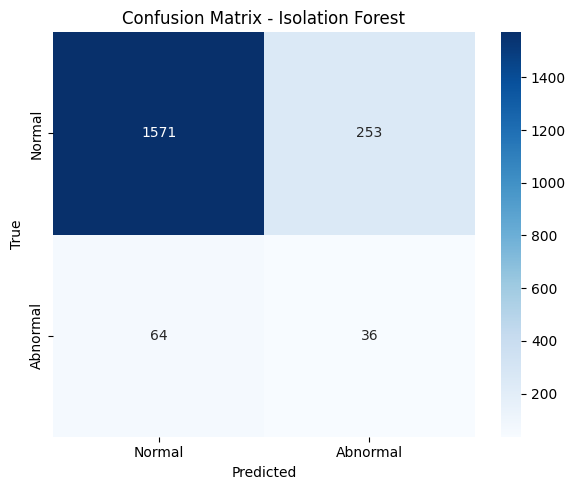

In [41]:
normal_df = normal_windowed_hrv.copy().reset_index(drop=True)
abnormal_df = abnormal_windowed_hrv.copy().reset_index(drop=True)

train_frac = 0.8
random_state = 42

normal_train_df = normal_windowed_hrv.sample(frac=train_frac, random_state=random_state)
normal_test_df = normal_windowed_hrv.drop(index=normal_train_df.index)

normal_train_df = normal_train_df.reset_index(drop=True)
normal_test_df = normal_test_df.reset_index(drop=True)

# Sample exactly 200 anomalies for test set
abnormal_test_df = abnormal_df.sample(n=min(100, len(abnormal_df)), random_state=random_state)

test_df = pd.concat([normal_test_df, abnormal_test_df], ignore_index=True)

df_train = normal_train_df.copy()
df_test = test_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF"]
X_train_if = df_train[feature_cols]
X_test_if = df_test[feature_cols]
y_test_if = df_test["label"].astype(int)

#Standardize features for Isolation Forest
scaler = StandardScaler()
X_train_if_scaled = scaler.fit_transform(X_train_if)
X_test_if_scaled = scaler.transform(X_test_if)

iso_forest = IsolationForest(n_estimators=500,
                             contamination=0.1, 
                             random_state=random_state,
                             max_features = 5,
                             )
iso_forest.fit(X_train_if_scaled)
scores = iso_forest.decision_function(X_test_if_scaled)
threshold = np.percentile(scores, 15)


# IsolationForest: 1=inlier(normal), -1=outlier(anomaly)
# y_pred_raw = iso_forest.predict(X_test_if_scaled)
# y_pred_if = (y_pred_raw == -1).astype(int)
y_pred_if = (scores < threshold).astype(int)


print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score
accuracy = accuracy_score(y_test_if, y_pred_if)
precision = precision_score(y_test_if, y_pred_if)
recall = recall_score(y_test_if, y_pred_if)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (reflects the reliability of the detected anomalies): {precision:.4f}")
print(f"Recall (ability of the model to correctly detect anomalies,):    {recall:.4f}")
cm_if = confusion_matrix(y_test_if, y_pred_if)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_if,
    annot=True,
    fmt="d", 
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
)
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

We struggle to find a balance between recall and precision

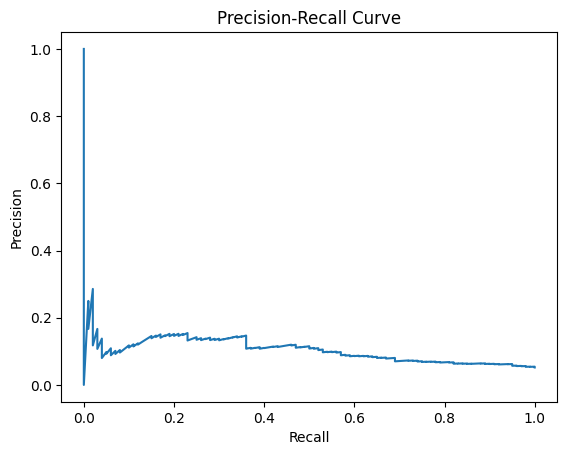

In [42]:
from sklearn.metrics import precision_recall_curve

# Compute precision-recall values
precision, recall, thresholds = precision_recall_curve(y_test_if, -scores)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

The model can't detect anomalies, it can be because the features are not very distinctive

Let's see what appen if we add features (RR_min, RR_max, RR_range, RR_diff_std, RR_diff_max)

In [43]:
from scipy.stats import skew, kurtosis

In [44]:
def compute_hrv_features(rr_intervals_ms):
    """
    Compute HRV features from RR intervals in milliseconds.
    
    Parameters:
    - rr_intervals_ms: numpy array of RR intervals in ms
    
    Returns:
    - dict with SDNN, RMSSD, pNN50, LF/HF ratio
    """
    rr_ms = np.array(rr_intervals_ms)
    
    rr_mean = np.mean(rr_ms)
    
    rr_min = np.min(rr_ms)
    
    rr_max = np.max(rr_ms)
    
    rr_range = rr_max - rr_min
    
    rr_diff = np.diff(rr_ms)
    
    rr_diff_max = np.max(np.abs(rr_diff))
    
    rr_diff_std = np.std(rr_diff) 
    
    rr_diff_mean = np.mean(np.abs(np.diff(rr_ms)))
    
    rr_acceleration = np.std(np.diff(np.diff(rr_ms)))
    
    sudden_jumps = np.sum(np.abs(rr_diff) > 100)
    extreme_jumps = np.sum(np.abs(rr_diff) > 200)

    relative_jump = np.max(np.abs(rr_diff)) / np.mean(rr_ms)

    outlier_count = np.sum(
    np.abs(rr_ms - np.mean(rr_ms)) > 2 * np.std(rr_ms)
    )      
    
    #rr_skewness = skew(rr_ms)
    
    #rr_kurtosis = kurtosis(rr_ms)
    
    sdnn = np.std(rr_ms)
    
    cv = sdnn / rr_mean if rr_mean != 0 else 0
    
    diff_rr = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff_rr ** 2))
    
    pnn50 = 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr)
    
    fft_result = np.fft.fft(rr_ms)
    freqs = np.fft.fftfreq(len(rr_ms), d=np.mean(rr_ms) / 1000)
    power = np.abs(fft_result) ** 2
    
    lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
    hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
    
    lf_power = np.sum(power[lf_mask])
    hf_power = np.sum(power[hf_mask])
    
    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0
    
    return {
        "RR_mean": rr_mean,
        "RR_min": rr_min,
        "RR_max": rr_max,
        "RR_range": rr_range,
        "RR_diff_max": rr_diff_max,
        "RR_diff_std": rr_diff_std,
        "RR_diff_mean": rr_diff_mean,
        "RR_acceleration": rr_acceleration,
        "sudden_jumps": sudden_jumps,
        "extreme_jumps": extreme_jumps,
        "relative_jump": relative_jump,
        "outlier_count": outlier_count,
        #"skewness": rr_skewness,
        #"kurtosis": rr_kurtosis,
        "SDNN": sdnn,
        "CV": cv,
        "RMSSD": rmssd,
        "pNN50": pnn50,
        "LF/HF": lf_hf_ratio,
    }


def hrv_windows(rr_ms, dataset_name, target_label, win=30, step=30):
    rows = []
    if len(rr_ms) < win:
        return pd.DataFrame()

    for start_idx in range(0, len(rr_ms) - win + 1, step):
        end_idx = start_idx + win
        rr_window = rr_ms[start_idx:end_idx]

        features = compute_hrv_features(rr_window)
        features["label"] = target_label
        features["dataset"] = dataset_name
        features["start_idx"] = start_idx
        features["end_idx"] = end_idx
        rows.append(features)

    return pd.DataFrame(rows)

normal_rr_ms = get_rr_ms(normal_merged, fs=sampling_rate_mitbih)
abnormal_rr_ms = get_rr_ms(abnormal_merged, fs=sampling_rate_mitbih)

normal_windowed_hrv = hrv_windows(normal_rr_ms, "normal_merged", 0, win=window_size, step=step_size)
abnormal_windowed_hrv = hrv_windows(abnormal_rr_ms, "abnormal_merged", 1, win=window_size, step=step_size)

normal_df = normal_windowed_hrv.copy().reset_index(drop=True)
abnormal_df = abnormal_windowed_hrv.copy().reset_index(drop=True)

train_frac = 0.8
random_state = 42

normal_train_df = normal_windowed_hrv.sample(frac=train_frac, random_state=random_state)
normal_test_df = normal_windowed_hrv.drop(index=normal_train_df.index)

normal_train_df = normal_train_df.reset_index(drop=True)
normal_test_df = normal_test_df.reset_index(drop=True)

# Sample exactly 200 anomalies for test set
abnormal_test_df = abnormal_df.sample(n=min(100, len(abnormal_df)), random_state=random_state)

test_df = pd.concat([normal_test_df, abnormal_test_df], ignore_index=True)

df_train = normal_train_df.copy()
df_test = test_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF","RR_max","RR_min","RR_range","RR_diff_max","RR_diff_std","RR_diff_mean","RR_acceleration","sudden_jumps","extreme_jumps","relative_jump","outlier_count"]
X_train_if = df_train[feature_cols]
X_test_if = df_test[feature_cols]
y_test_if = df_test["label"].astype(int)

#Standardize features for Isolation Forest
scaler = StandardScaler()
X_train_if_scaled = scaler.fit_transform(X_train_if)
X_test_if_scaled = scaler.transform(X_test_if)

df_train shape: (7298, 21)
df_test shape: (1924, 21)
Accuracy:  0.8352
Precision (reflects the reliability of the detected anomalies): 0.1246
Recall (ability of the model to correctly detect anomalies,):    0.3600


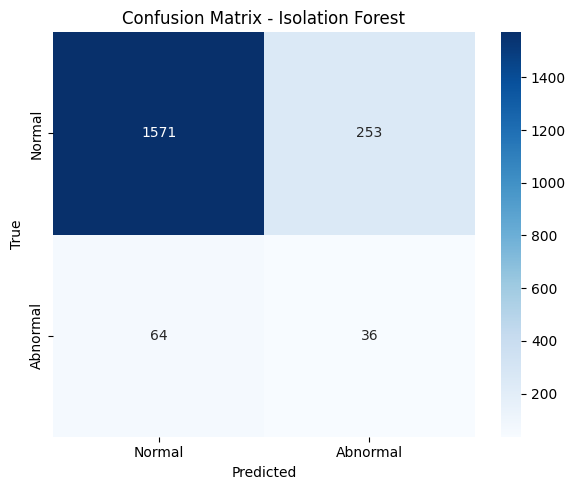

In [45]:
iso_forest = IsolationForest(n_estimators=500,
                             contamination=0.1, 
                             random_state=random_state,
                             max_features = 5,
                             )
iso_forest.fit(X_train_if_scaled)
scores = iso_forest.decision_function(X_test_if_scaled)
threshold = np.percentile(scores, 15)


# IsolationForest: 1=inlier(normal), -1=outlier(anomaly)
# y_pred_raw = iso_forest.predict(X_test_if_scaled)
# y_pred_if = (y_pred_raw == -1).astype(int)
y_pred_if = (scores < threshold).astype(int)


print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score
accuracy = accuracy_score(y_test_if, y_pred_if)
precision = precision_score(y_test_if, y_pred_if)
recall = recall_score(y_test_if, y_pred_if)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (reflects the reliability of the detected anomalies): {precision:.4f}")
print(f"Recall (ability of the model to correctly detect anomalies,):    {recall:.4f}")
cm_if = confusion_matrix(y_test_if, y_pred_if)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_if,
    annot=True,
    fmt="d", 
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
)
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

We'll try to reduce the windows size

df_train shape: (14596, 21)
df_test shape: (3749, 21)
Accuracy:  0.7978
Precision (reflects the reliability of the detected anomalies): 0.0613
Recall (ability of the model to correctly detect anomalies,):    0.4600


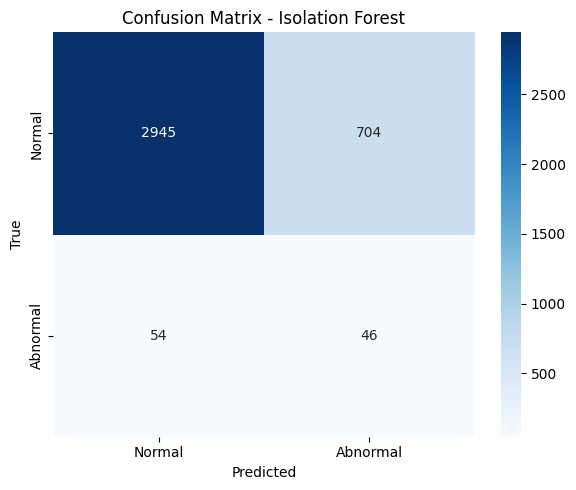

In [46]:
sampling_rate_mitbih = 125
window_size = 15
step_size = window_size

normal_rr_ms = get_rr_ms(normal_merged, fs=sampling_rate_mitbih)
abnormal_rr_ms = get_rr_ms(abnormal_merged, fs=sampling_rate_mitbih)

normal_windowed_hrv = hrv_windows(normal_rr_ms, "normal_merged", 0, win=window_size, step=step_size)
abnormal_windowed_hrv = hrv_windows(abnormal_rr_ms, "abnormal_merged", 1, win=window_size, step=step_size)

normal_df = normal_windowed_hrv.copy().reset_index(drop=True)
abnormal_df = abnormal_windowed_hrv.copy().reset_index(drop=True)

train_frac = 0.8
random_state = 42

normal_train_df = normal_windowed_hrv.sample(frac=train_frac, random_state=random_state)
normal_test_df = normal_windowed_hrv.drop(index=normal_train_df.index)

normal_train_df = normal_train_df.reset_index(drop=True)
normal_test_df = normal_test_df.reset_index(drop=True)

# Sample exactly 200 anomalies for test set
abnormal_test_df = abnormal_df.sample(n=min(100, len(abnormal_df)), random_state=random_state)

test_df = pd.concat([normal_test_df, abnormal_test_df], ignore_index=True)

df_train = normal_train_df.copy()
df_test = test_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

feature_cols = ["RR_mean", "SDNN", "RMSSD", "pNN50", "LF/HF","RR_max","CV","RR_min","RR_range","RR_diff_max","RR_diff_std","RR_diff_mean","RR_acceleration","sudden_jumps","extreme_jumps","relative_jump","outlier_count"]
X_train_if = df_train[feature_cols]
X_test_if = df_test[feature_cols]
y_test_if = df_test["label"].astype(int)

#Standardize features for Isolation Forest
scaler = StandardScaler()
X_train_if_scaled = scaler.fit_transform(X_train_if)
X_test_if_scaled = scaler.transform(X_test_if)

iso_forest = IsolationForest(n_estimators=500,
                             contamination=0.15, 
                             random_state=random_state,
                             max_features = 17,
                             )
iso_forest.fit(X_train_if_scaled)
scores = iso_forest.decision_function(X_test_if_scaled)
threshold = np.percentile(scores, 20)


# IsolationForest: 1=inlier(normal), -1=outlier(anomaly)
# y_pred_raw = iso_forest.predict(X_test_if_scaled)
# y_pred_if = (y_pred_raw == -1).astype(int)
y_pred_if = (scores < threshold).astype(int)


print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)

# Calculate metrics
from sklearn.metrics import precision_score, recall_score
accuracy = accuracy_score(y_test_if, y_pred_if)
precision = precision_score(y_test_if, y_pred_if)
recall = recall_score(y_test_if, y_pred_if)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (reflects the reliability of the detected anomalies): {precision:.4f}")
print(f"Recall (ability of the model to correctly detect anomalies,):    {recall:.4f}")
cm_if = confusion_matrix(y_test_if, y_pred_if)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_if,
    annot=True,
    fmt="d", 
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"],
)
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()




One-Class SVM

Index(['RR_mean', 'RR_min', 'RR_max', 'RR_range', 'RR_diff_max', 'RR_diff_std',
       'RR_diff_mean', 'RR_acceleration', 'sudden_jumps', 'extreme_jumps',
       'relative_jump', 'outlier_count', 'SDNN', 'CV', 'RMSSD', 'pNN50',
       'LF/HF', 'label', 'dataset', 'start_idx', 'end_idx'],
      dtype='object')
Accuracy: 0.8863696985862897
Precision: 0.08838383838383838
Recall: 0.35
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      3649
           1       0.09      0.35      0.14       100

    accuracy                           0.89      3749
   macro avg       0.53      0.63      0.54      3749
weighted avg       0.96      0.89      0.92      3749

Confusion matrix:
 [[3288  361]
 [  65   35]]


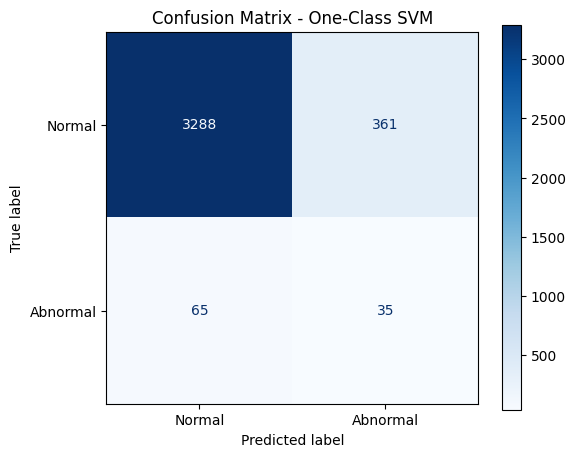

In [47]:
# One-Class SVM on df_train / df_test
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import matplotlib.pyplot as plt

print(df_train.columns)

# Train only on normal samples
X_train = df_train.drop(columns=['label', 'dataset', 'start_idx', 'end_idx'])
X_test = df_test.drop(columns=['label', 'dataset', 'start_idx', 'end_idx'])
y_test = df_test['label'].astype(int)

ocsvm = OneClassSVM(kernel='poly', nu=0.1, gamma='scale')
ocsvm.fit(X_train)

# OneClassSVM predicts 1 for inliers, -1 for outliers
y_pred = ocsvm.predict(X_test)
y_pred = (y_pred == -1).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - One-Class SVM')
plt.show()

We see wich feature is interresting

j'arrive pas jv péter un plomb

Try to create frequency feature

Maybe the data has a lot of noise so it's difficuolt for the forest to know what is really abnormal or just noise

We can try window sliding